In [2]:
# Model Evaluation Lab
# Complete the exercises by filling in the code where indicated with TODO

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, roc_auc_score,
    mean_absolute_error, mean_squared_error, r2_score
)
from sklearn.datasets import load_breast_cancer, load_diabetes
import warnings
warnings.filterwarnings('ignore')

print("=" * 80)
print("MODEL EVALUATION LAB - STUDENT VERSION")
print("=" * 80)


MODEL EVALUATION LAB - STUDENT VERSION


In [7]:
# ============================================================================
# Load Dataset
# ============================================================================
# Load built-in breast cancer dataset from sklearn
data = load_breast_cancer()
# Create feature matrix (X)
X = pd.DataFrame(data.data, columns=data.feature_names)
# Create target variable (y)
y = pd.Series(data.target, name="target")
print(f"\nDataset Shape: {X.shape}")
print(f"Number of Features: {X.shape[1]}")
print(f"Number of Samples: {X.shape[0]}")
print("\nClass Distribution:")
print(y.value_counts())


Dataset Shape: (569, 30)
Number of Features: 30
Number of Samples: 569

Class Distribution:
target
1    357
0    212
Name: count, dtype: int64


# Exercise 1.1: Train-Test Split


In [9]:
print("\n" + "-" * 80)
print("Exercise 1.1: Train-Test Split")
print("-" * 80)
# Split data into 80% training and 20% test
# stratify=y keeps class distribution same in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
# Standardize features
scaler = StandardScaler()
# Learn mean & std from training data and scale it
X_train_scaled = scaler.fit_transform(X_train)
# to transform the test data 
X_test_scaled = scaler.transform(X_test)
print("Feature scaling completed successfully.")



--------------------------------------------------------------------------------
Exercise 1.1: Train-Test Split
--------------------------------------------------------------------------------
Training set size: 455
Test set size: 114
Feature scaling completed successfully.


# Exercise 1.2:Train and Evaluate Logistic Regression

In [10]:
print("\n" + "-" * 80)
print("Exercise 1.2: Train and Evaluate Logistic Regression")
print("-" * 80)
# Creating the Logistic Regression model
# max_iter=10000 ensures the model has enough iterations to converge
# random_state=42 ensures reproducibility
log_reg = LogisticRegression(max_iter=10000, random_state=42)
# Train (fit) the model on the scaled training data
log_reg.fit(X_train_scaled, y_train)
#  predictions on the training set
y_pred_train = log_reg.predict(X_train_scaled)
# predictions on the test set
y_pred_test = log_reg.predict(X_test_scaled)
# Calculate accuracy for both sets
train_accuracy = accuracy_score(y_train, y_pred_train)
test_accuracy = accuracy_score(y_test, y_pred_test)
# Print the accuracies
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
# interpret the results
if train_accuracy - test_accuracy > 0.05:
    print("The model may be slightly overfitting (training accuracy is much higher than test accuracy).")
elif test_accuracy > train_accuracy:
    print("The model might be slightly underfitting.")
else:
    print("The model appears well-fitted (training and test accuracy are close).")



--------------------------------------------------------------------------------
Exercise 1.2: Train and Evaluate Logistic Regression
--------------------------------------------------------------------------------
Training Accuracy: 0.9890
Test Accuracy: 0.9825
The model appears well-fitted (training and test accuracy are close).


# Exercise 1.3: Confusion Matrix Analysis


--------------------------------------------------------------------------------
Exercise 1.3: Confusion Matrix Analysis
--------------------------------------------------------------------------------

Confusion Matrix:
[[41  1]
 [ 1 71]]

True Negatives (TN): 41
False Positives (FP): 1
False Negatives (FN): 1
True Positives (TP): 71

Manual Calculations:
Accuracy  : 0.9825
Precision : 0.9861
Recall    : 0.9861
F1 Score  : 0.9861


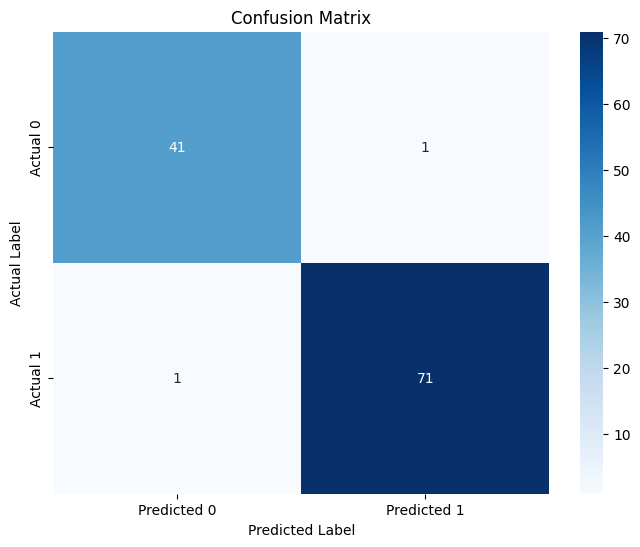

In [12]:
print("\n" + "-" * 80)
print("Exercise 1.3: Confusion Matrix Analysis")
print("-" * 80)
# Create confusion matrix using test predictions
cm = confusion_matrix(y_test, y_pred_test)
print("\nConfusion Matrix:")
print(cm)
# Extract TN, FP, FN, TP
# confusion_matrix layout:
# [[TN  FP]
#  [FN  TP]]
tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Negatives (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives (TP): {tp}")
# Manually calculate evaluation metrics
manual_accuracy = (tp + tn) / (tp + tn + fp + fn)
manual_precision = tp / (tp + fp)
manual_recall = tp / (tp + fn)
manual_f1 = 2 * (manual_precision * manual_recall) / (manual_precision + manual_recall)
print("\nManual Calculations:")
print(f"Accuracy  : {manual_accuracy:.4f}")
print(f"Precision : {manual_precision:.4f}")
print(f"Recall    : {manual_recall:.4f}")
print(f"F1 Score  : {manual_f1:.4f}")
# Visualize Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Predicted 0', 'Predicted 1'],
    yticklabels=['Actual 0', 'Actual 1']
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.savefig('confusion_matrix_student.png')
plt.show()


# Exercise 1.4: Precision, Recall, and F1 Score

In [15]:
print("\n" + "-" * 80)
print("Exercise 1.4: Precision, Recall, and F1 Score")
print("-" * 80)
# Calculate metrics using sklearn functions
precision = precision_score(y_test, y_pred_test)
recall = recall_score(y_test, y_pred_test)
f1 = f1_score(y_test, y_pred_test)
print(f"\nPrecision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
# Interpretation
print("\nInterpretation:")
print(f"Of all predicted positive (Benign) cases, {precision*100:.2f}% are actually benign.")
print(f"Of all actual benign cases, {recall*100:.2f}% were correctly identified.")
print(f"The F1-score balances precision and recall at {f1*100:.2f}%.")
# Full Classification Report
print("\nFull Classification Report:")
print(classification_report(
    y_test,
    y_pred_test,
    target_names=['Malignant', 'Benign']
))



--------------------------------------------------------------------------------
Exercise 1.4: Precision, Recall, and F1 Score
--------------------------------------------------------------------------------

Precision: 0.9861
Recall   : 0.9861
F1 Score : 0.9861

Interpretation:
Of all predicted positive (Benign) cases, 98.61% are actually benign.
Of all actual benign cases, 98.61% were correctly identified.
The F1-score balances precision and recall at 98.61%.

Full Classification Report:
              precision    recall  f1-score   support

   Malignant       0.98      0.98      0.98        42
      Benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



# Exercise 1.5: ROC Curve and AUC

In [ ]:
print("\n" + "-" * 80)
print("Exercise 1.5: ROC Curve and AUC")
print("-" * 80)
# Get predicted probabilities for the positive class 
y_pred_proba = log_reg.predict_proba(X_test_scaled)[:, 1]
# Calculate ROC curve coordinates
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
# Calculate AUC score
auc_score = roc_auc_score(y_test, y_pred_proba)
print(f"\nAUC Score: {auc_score:.4f}")
# Interpretation
if auc_score >= 0.9:
    print("Model Performance: Excellent")
elif auc_score >= 0.8:
    print("Model Performance: Good")
elif auc_score >= 0.7:
    print("Model Performance: Acceptable")
else:
    print("Model Performance: Poor")
# Plot ROC Curve
plt.figure(figsize=(8, 6))
# Plot ROC curve
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {auc_score:.4f})")
# Plot diagonal line (random classifier)
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.savefig("roc_curve_student.png")
plt.show()


# Exercise 1.6: K-Fold Cross-Validation
# Task: Perform 5-fold stratified cross-validation

In [18]:
print("\n" + "-" * 80)
print("Exercise 1.6: K-Fold Cross-Validation")
print("-" * 80)
# Create StratifiedKFold with 5 splits
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# Scale the entire dataset
# For proper production code, scaling should be done inside a Pipeline.
scaler_full = StandardScaler()
X_scaled_full = scaler_full.fit_transform(X)
# Create model
log_reg_cv = LogisticRegression(max_iter=10000, random_state=42)
# Perform cross-validation
cv_scores = cross_val_score(
    log_reg_cv,
    X_scaled_full,
    y,
    cv=kfold,
    scoring='accuracy'
)
# Print individual fold scores
print("\nCross-Validation Scores:")
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {score:.4f}")
# Calculate mean and standard deviation
mean_cv = np.mean(cv_scores)
std_cv = np.std(cv_scores)
print(f"\nMean CV Accuracy: {mean_cv:.4f}")
print(f"Standard Deviation: {std_cv:.4f}")
# 95% Confidence Interval
confidence_interval = 1.96 * (std_cv / np.sqrt(len(cv_scores)))
lower_bound = mean_cv - confidence_interval
upper_bound = mean_cv + confidence_interval
print(f"95% Confidence Interval: ({lower_bound:.4f}, {upper_bound:.4f})")
# Compare with single train-test split accuracy
print("\nComparison with Single Train-Test Split:")
print(f"Train-Test Accuracy: {test_accuracy:.4f}")
print(f"Cross-Validation Mean Accuracy: {mean_cv:.4f}")
if abs(test_accuracy - mean_cv) < 0.02:
    print("Both methods give similar performance → Model is stable.")
else:
    print("There is noticeable variation → Cross-validation gives more reliable estimate.")



--------------------------------------------------------------------------------
Exercise 1.6: K-Fold Cross-Validation
--------------------------------------------------------------------------------

Cross-Validation Scores:
  Fold 1: 0.9737
  Fold 2: 0.9474
  Fold 3: 0.9649
  Fold 4: 0.9912
  Fold 5: 0.9912

Mean CV Accuracy: 0.9737
Standard Deviation: 0.0166
95% Confidence Interval: (0.9591, 0.9882)

Comparison with Single Train-Test Split:
Train-Test Accuracy: 0.9825
Cross-Validation Mean Accuracy: 0.9737
Both methods give similar performance → Model is stable.


# Exercise 1.7: Compare Multiple Classifiers
# Task: Train and compare Logistic Regression, Decision Tree, and Random Forest

In [19]:
print("\n" + "-" * 80)
print("Exercise 1.7: Compare Multiple Classifiers")
print("-" * 80)
# Define models
models = {
    'Logistic Regression': LogisticRegression(max_iter=10000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

results = []
# Loop through each model
for name, model in models.items():
    
    # Train the model
    model.fit(X_train_scaled, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    # Calculate metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1_val = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred_proba)
    
    # Append results
    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1 Score': f1_val,
        'AUC': auc
    })

# Create comparison DataFrame
results_df = pd.DataFrame(results)
print("\nModel Comparison:")
print(results_df.to_string(index=False))
# Identify best model by F1 Score
best_model = results_df.loc[results_df['F1 Score'].idxmax()]
print("\nBest Model Based on F1 Score:")
print(f"Model: {best_model['Model']}")
print(f"F1 Score: {best_model['F1 Score']:.4f}")


--------------------------------------------------------------------------------
Exercise 1.7: Compare Multiple Classifiers
--------------------------------------------------------------------------------

Model Comparison:
              Model  Accuracy  Precision   Recall  F1 Score      AUC
Logistic Regression  0.982456   0.986111 0.986111  0.986111 0.995370
      Decision Tree  0.921053   0.956522 0.916667  0.936170 0.916336
      Random Forest  0.956140   0.958904 0.972222  0.965517 0.993882

Best Model Based on F1 Score:
Model: Logistic Regression
F1 Score: 0.9861



# PART 2: REGRESSION EVALUATION


In [21]:
# ============================================================================
# PART 2: REGRESSION EVALUATION
# ============================================================================
print("\n" + "=" * 80)
print("PART 2: REGRESSION EVALUATION - DIABETES DATASET")
print("=" * 80)
# Load the diabetes dataset from sklearn
diabetes = load_diabetes()
# Create feature matrix (X)
X_reg = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
# Create target variable (y)
y_reg = pd.Series(diabetes.target, name='target')
print(f"\nDataset Shape: {X_reg.shape}")
print(f"Number of Features: {X_reg.shape[1]}")
print(f"Number of Samples: {X_reg.shape[0]}")
print(f"\nTarget Statistics:")
print(y_reg.describe())


PART 2: REGRESSION EVALUATION - DIABETES DATASET

Dataset Shape: (442, 10)
Number of Features: 10
Number of Samples: 442

Target Statistics:
count    442.000000
mean     152.133484
std       77.093005
min       25.000000
25%       87.000000
50%      140.500000
75%      211.500000
max      346.000000
Name: target, dtype: float64


# Exercise 2.1: Train-Test Split for Regression
# Task: Split regression data into training and test sets

In [22]:
print("\n" + "-" * 80)
print("Exercise 2.1: Train-Test Split for Regression")
print("-" * 80)
# Split the regression data into 80% training and 20% testing
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)
# Print set sizes
print(f"Training set size: {X_train_reg.shape[0]}")
print(f"Test set size: {X_test_reg.shape[0]}")

# Standardize features
scaler_reg = StandardScaler()
# Learn mean & std from training data and scale it
X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)
# Apply the same scaling to test data (no refitting)
X_test_reg_scaled = scaler_reg.transform(X_test_reg)
print("Feature scaling completed successfully.")



--------------------------------------------------------------------------------
Exercise 2.1: Train-Test Split for Regression
--------------------------------------------------------------------------------
Training set size: 353
Test set size: 89
Feature scaling completed successfully.


# Exercise 2.2: Train Linear Regression and Calculate Metrics
# Task: Train linear regression and calculate MAE, MSE, RMSE, R²

In [23]:
print("\n" + "-" * 80)
print("Exercise 2.2: Train Linear Regression and Calculate Metrics")
print("-" * 80)
# Create Linear Regression model
lin_reg = LinearRegression()
# Train the model on scaled training data
lin_reg.fit(X_train_reg_scaled, y_train_reg)
# Make predictions
y_pred_train_reg = lin_reg.predict(X_train_reg_scaled)
y_pred_test_reg = lin_reg.predict(X_test_reg_scaled)
# Calculate  MAE for both sets
train_mae = mean_absolute_error(y_train_reg, y_pred_train_reg)
test_mae = mean_absolute_error(y_test_reg, y_pred_test_reg)
# Calculate Mse for both sets
train_mse = mean_squared_error(y_train_reg, y_pred_train_reg)
test_mse = mean_squared_error(y_test_reg, y_pred_test_reg)
# Calculate RMSE for both sets
train_rmse = np.sqrt(train_mse)
test_rmse = np.sqrt(test_mse)
# Calculate R² score for both sets
train_r2 = r2_score(y_train_reg, y_pred_train_reg)
test_r2 = r2_score(y_test_reg, y_pred_test_reg)
# Print Results
print("\nTraining Metrics:")
print(f"MAE  : {train_mae:.4f}")
print(f"MSE  : {train_mse:.4f}")
print(f"RMSE : {train_rmse:.4f}")
print(f"R²   : {train_r2:.4f}")

print("\nTest Metrics:")
print(f"MAE  : {test_mae:.4f}")
print(f"MSE  : {test_mse:.4f}")
print(f"RMSE : {test_rmse:.4f}")
print(f"R²   : {test_r2:.4f}")

# Interpretation
print("\nInterpretation:")
print(f"On average, the model's prediction error is about {test_mae:.2f} units.")
print(f"The model explains approximately {test_r2*100:.2f}% of the variance in the target variable.")



--------------------------------------------------------------------------------
Exercise 2.2: Train Linear Regression and Calculate Metrics
--------------------------------------------------------------------------------

Training Metrics:
MAE  : 43.4835
MSE  : 2868.5497
RMSE : 53.5588
R²   : 0.5279

Test Metrics:
MAE  : 42.7941
MSE  : 2900.1936
RMSE : 53.8534
R²   : 0.4526

Interpretation:
On average, the model's prediction error is about 42.79 units.
The model explains approximately 45.26% of the variance in the target variable.


# Exercise 2.3: Visualize Predictions vs Actual
# Task: Create scatter plots comparing predictions to actual values


--------------------------------------------------------------------------------
Exercise 2.3: Visualize Predictions vs Actual
--------------------------------------------------------------------------------


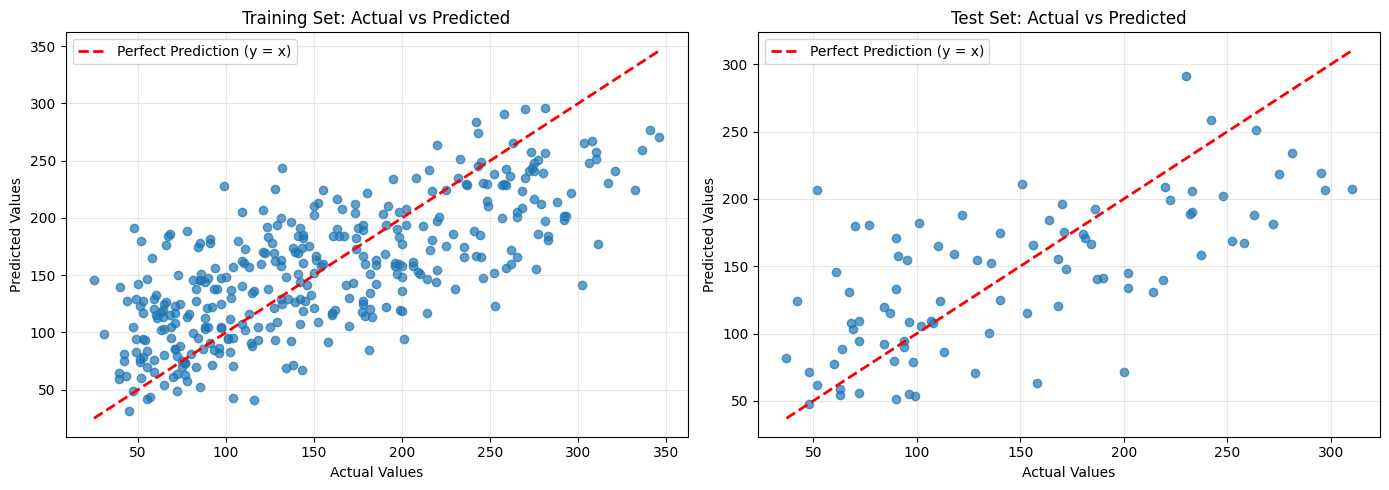


Visualization displayed and saved successfully.


In [25]:
print("\n" + "-" * 80)
print("Exercise 2.3: Visualize Predictions vs Actual")
print("-" * 80)
# Create figure with 2 subplots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Training Set Plot
axes[0].scatter(y_train_reg, y_pred_train_reg, alpha=0.7)
axes[0].plot(
    [y_train_reg.min(), y_train_reg.max()],
    [y_train_reg.min(), y_train_reg.max()],
    'r--',
    linewidth=2,
    label='Perfect Prediction (y = x)'
)

axes[0].set_xlabel("Actual Values")
axes[0].set_ylabel("Predicted Values")
axes[0].set_title("Training Set: Actual vs Predicted")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
# Test Set Plot
axes[1].scatter(y_test_reg, y_pred_test_reg, alpha=0.7)
axes[1].plot(
    [y_test_reg.min(), y_test_reg.max()],
    [y_test_reg.min(), y_test_reg.max()],
    'r--',
    linewidth=2,
    label='Perfect Prediction (y = x)'
)
axes[1].set_xlabel("Actual Values")
axes[1].set_ylabel("Predicted Values")
axes[1].set_title("Test Set: Actual vs Predicted")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
# Adjust spacing
plt.tight_layout()
# Save the image
plt.savefig("regression_predictions_student.png")
# Display the plot in Jupyter output
plt.show()
print("\nVisualization displayed and saved successfully.")

# Exercise 2.4: Residual Analysis
# Task: Calculate and visualize residuals


--------------------------------------------------------------------------------
Exercise 2.4: Residual Analysis
--------------------------------------------------------------------------------

Residual Statistics:
Mean Residual: 3.9128
Standard Deviation: 54.0154
Minimum Residual: -154.4934
Maximum Residual: 128.3333

Interpretation:
- Mean should be close to 0 (indicates unbiased predictions)
- Smaller standard deviation means better predictions
- Large min/max values indicate outliers


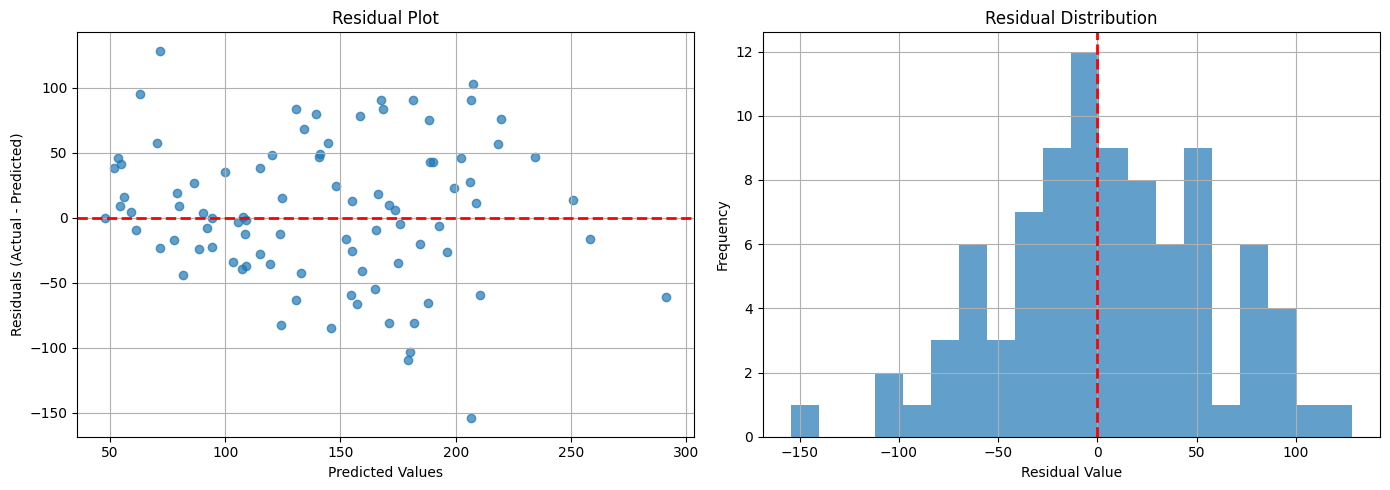


Residual analysis completed and saved successfully.


In [27]:
print("\n" + "-" * 80)
print("Exercise 2.4: Residual Analysis")
print("-" * 80)
# Calculate residuals (actual - predicted) for test set
residuals = y_test_reg - y_pred_test_reg
# Print residual statistics
print("\nResidual Statistics:")
print(f"Mean Residual: {residuals.mean():.4f}")
print(f"Standard Deviation: {residuals.std():.4f}")
print(f"Minimum Residual: {residuals.min():.4f}")
print(f"Maximum Residual: {residuals.max():.4f}")
# Interpretation
print("\nInterpretation:")
print("- Mean should be close to 0 (indicates unbiased predictions)")
print("- Smaller standard deviation means better predictions")
print("- Large min/max values indicate outliers")
# Create figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Left Plot: Residual Plot
axes[0].scatter(y_pred_test_reg, residuals, alpha=0.7)
axes[0].axhline(y=0, linestyle='--', linewidth=2, color='red')
axes[0].set_xlabel("Predicted Values")
axes[0].set_ylabel("Residuals (Actual - Predicted)")
axes[0].set_title("Residual Plot")
axes[0].grid(True)
# Right Plot: Residual Distribution
axes[1].hist(residuals, bins=20, alpha=0.7)
axes[1].axvline(x=0, linestyle='--', linewidth=2, color='red')
axes[1].set_xlabel("Residual Value")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Residual Distribution")
axes[1].grid(True)
# Adjust layout
plt.tight_layout()
# Save figure
plt.savefig('residual_analysis_student.png')
# Show in Jupyter output
plt.show()
print("\nResidual analysis completed and saved successfully.")


# Exercise 2.5: Compare Multiple Regression Models
# Task: Compare Linear Regression, Ridge (two alpha values), and Decision 

In [28]:
print("\n" + "-" * 80)
print("Exercise 2.5: Compare Multiple Regression Models")
print("-" * 80)
# Define regression models
reg_models = {
    'Linear Regression': LinearRegression(),
    'Ridge (alpha=1.0)': Ridge(alpha=1.0),
    'Ridge (alpha=10.0)': Ridge(alpha=10.0),
    'Decision Tree': DecisionTreeRegressor(max_depth=5, random_state=42)
}
reg_results = []
# Loop through models
for name, model in reg_models.items():
    # Use scaled data for linear models
    if "Tree" in name:
        model.fit(X_train_reg, y_train_reg)
        y_pred_train = model.predict(X_train_reg)
        y_pred_test = model.predict(X_test_reg)
    else:
        model.fit(X_train_reg_scaled, y_train_reg)
        y_pred_train = model.predict(X_train_reg_scaled)
        y_pred_test = model.predict(X_test_reg_scaled)
    # Calculate metrics
    train_r2_val = r2_score(y_train_reg, y_pred_train)
    test_r2_val = r2_score(y_test_reg, y_pred_test)
    test_mae_val = mean_absolute_error(y_test_reg, y_pred_test)
    test_rmse_val = np.sqrt(mean_squared_error(y_test_reg, y_pred_test))
    # Overfitting gap
    overfit_gap = train_r2_val - test_r2_val
    # Append results
    reg_results.append({
        'Model': name,
        'Train R²': round(train_r2_val, 4),
        'Test R²': round(test_r2_val, 4),
        'MAE': round(test_mae_val, 4),
        'RMSE': round(test_rmse_val, 4),
        'Overfit Gap': round(overfit_gap, 4)
    })
# Create DataFrame
reg_results_df = pd.DataFrame(reg_results)
print("\nRegression Model Comparison:")
print(reg_results_df.to_string(index=False))
# Identify best model by Test R²
best_model = reg_results_df.loc[reg_results_df['Test R²'].idxmax()]
print("\nBest Model Based on Test R²:")
print(best_model)


--------------------------------------------------------------------------------
Exercise 2.5: Compare Multiple Regression Models
--------------------------------------------------------------------------------

Regression Model Comparison:
             Model  Train R²  Test R²     MAE    RMSE  Overfit Gap
 Linear Regression    0.5279   0.4526 42.7941 53.8534       0.0753
 Ridge (alpha=1.0)    0.5276   0.4541 42.8120 53.7775       0.0735
Ridge (alpha=10.0)    0.5248   0.4572 42.8568 53.6263       0.0676
     Decision Tree    0.6686   0.3345 45.9370 59.3803       0.3341

Best Model Based on Test R²:
Model          Ridge (alpha=10.0)
Train R²                   0.5248
Test R²                    0.4572
MAE                       42.8568
RMSE                      53.6263
Overfit Gap                0.0676
Name: 2, dtype: object


# Exercise 2.6: Cross-Validation for Regression
# Task: Perform 5-fold cross-validation for regression

In [29]:
print("\n" + "-" * 80)
print("Exercise 2.6: Cross-Validation for Regression")
print("-" * 80)
# Scale full dataset
scaler_full = StandardScaler()
X_reg_scaled_full = scaler_full.fit_transform(X_reg)
# Use Ridge (alpha=1.0) as example model
model_cv = Ridge(alpha=1.0)
# Perform 5-fold Cross-Validation for R²
cv_r2_scores = cross_val_score(
    model_cv,
    X_reg_scaled_full,
    y_reg,
    cv=5,
    scoring='r2'
)
# Perform 5-fold Cross-Validation for MAE
cv_mae_scores = cross_val_score(
    model_cv,
    X_reg_scaled_full,
    y_reg,
    cv=5,
    scoring='neg_mean_absolute_error'
)
cv_mae_scores = -cv_mae_scores  # Convert to positive
# Print Results
print("\nR² Scores for each fold:")
print(cv_r2_scores)
print(f"Mean R²: {cv_r2_scores.mean():.4f}")
print(f"Standard Deviation of R²: {cv_r2_scores.std():.4f}")
print("\nMAE Scores for each fold:")
print(cv_mae_scores)
print(f"Mean MAE: {cv_mae_scores.mean():.4f}")
print(f"Standard Deviation of MAE: {cv_mae_scores.std():.4f}")
print("\nInterpretation:")
print("- Higher mean R² indicates better overall model performance.")
print("- Lower mean MAE indicates lower prediction error.")
print("- Small standard deviation means model is stable across folds.")


--------------------------------------------------------------------------------
Exercise 2.6: Cross-Validation for Regression
--------------------------------------------------------------------------------

R² Scores for each fold:
[0.42799486 0.5216558  0.48559778 0.42718752 0.54853736]
Mean R²: 0.4822
Standard Deviation of R²: 0.0489

MAE Scores for each fold:
[43.10369755 44.85951839 47.98250616 42.95473051 42.42036531]
Mean MAE: 44.2642
Standard Deviation of MAE: 2.0318

Interpretation:
- Higher mean R² indicates better overall model performance.
- Lower mean MAE indicates lower prediction error.
- Small standard deviation means model is stable across folds.


# PART 3: OVERFITTING AND UNDERFITTING DEMONSTRATION


PART 3: OVERFITTING AND UNDERFITTING DEMONSTRATION

Decision Tree Depth Analysis:
Depth     Train R²       Test R²        Gap            Status
----------------------------------------------------------------------
1         0.3043         0.1305         0.1738         Underfitting
3         0.5170         0.3294         0.1875         Good Fit
5         0.6686         0.3345         0.3341         Overfitting
10        0.9382         0.1718         0.7664         Overfitting
20        1.0000         0.0776         0.9224         Overfitting


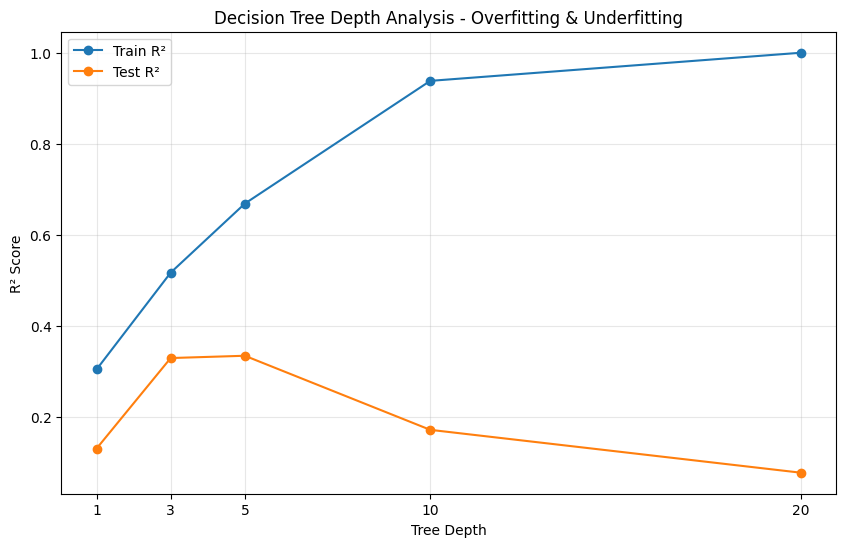

In [31]:
print("\n" + "=" * 80)
print("PART 3: OVERFITTING AND UNDERFITTING DEMONSTRATION")
print("=" * 80)
from sklearn.tree import DecisionTreeRegressor
import matplotlib.pyplot as plt
# Test different tree depths
depths = [1, 3, 5, 10, 20]
train_scores = []
test_scores = []
print("\nDecision Tree Depth Analysis:")
print(f"{'Depth':<10}{'Train R²':<15}{'Test R²':<15}{'Gap':<15}{'Status'}")
print("-" * 70)
# Loop through each depth
for depth in depths:
    # Create DecisionTreeRegressor with this depth
    tree = DecisionTreeRegressor(max_depth=depth, random_state=42)
    # Train on scaled training data
    tree.fit(X_train_reg_scaled, y_train_reg)
    # Calculate R² scores
    train_score = tree.score(X_train_reg_scaled, y_train_reg)
    test_score = tree.score(X_test_reg_scaled, y_test_reg)
    # Calculate train-test gap
    gap = train_score - test_score
    # Append to lists
    train_scores.append(train_score)
    test_scores.append(test_score)
    # Determine status
    if gap > 0.3:
        status = "Overfitting"
    elif test_score < 0.3:
        status = "Underfitting"
    else:
        status = "Good Fit"
    # Print results
    print(f"{depth:<10}{train_score:<15.4f}{test_score:<15.4f}{gap:<15.4f}{status}")
# Plot Learning Curves
plt.figure(figsize=(10, 6))
plt.plot(depths, train_scores, marker='o', label='Train R²')
plt.plot(depths, test_scores, marker='o', label='Test R²')
plt.xlabel("Tree Depth")
plt.ylabel("R² Score")
plt.title("Decision Tree Depth Analysis - Overfitting & Underfitting")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(depths)
plt.show()
# plt.savefig('overfitting_analysis_student.png')  # Optional save
# plt.close()




1. What is the difference between accuracy and F1 score? When would you prefer F1 score over accuracy?
Answer:
.Accuracy** measures the overall percentage of correct predictions
.F1 Score** is the harmonic mean of precision and recall
.Use F1 score** when dealing with **imbalanced datasets, where accuracy can be misleading. For example, if 95% of data is negative, predicting all negatives gives 95% accuracy but F1 = 0.

2. Explain the difference between precision and recall. Give an example of when you would optimize for high precision vs high recall.
Answer:
.Precision: Out of all predicted positives, how many are actually positive.
.Recall: Out of all actual positives, how many were correctly predicted.
.High precision example: Email spam filter → Avoid marking legitimate emails as spam.
.High recall example: Disease screening → Detect all patients, even if some false positives occur.

3. What does an AUC score of 0.5 indicate? What about 1.0?
Answer:
AUC = 0.5 → Model performs no better than random guessing
AUC = 1.0 → Model perfectly separates positive and negative classes.

4. Why do we use cross-validation instead of a single train-test split?
Answer:
.Cross-validation reduces variance in performance estimates.
.Provides a more reliable measure of model performance across different subsets of data.
.Ensures the model is not biased by a particular train-test split.

5. What is the difference between MAE and RMSE? When would each be preferred?
Answer
.MAE (Mean Absolute Error: Average of absolute differences. Less sensitive to outliers.
.RMSE (Root Mean Squared Error): Square root of average squared differences. Penalizes large errors more.
.MAE preferred: When all errors are equally important.
.RMSE preferred: When large errors are especially undesirable.

6. What does an R² score of 0.7 mean? What about a negative R² score?
Answer:
.R² = 0.7 → Model explains 70% of variance** in the target variable.
.R² < 0→ Model performs worse than predicting the mean, indicating poor fit.

7. How can you identify overfitting from looking at training and test scores? What are some strategies to reduce overfitting?
Answer:
.Overfitting → Training score high, test score much lower.
.Strategies to reduce overfitting:
   Reduce model complexity (e.g., shallower tree)
   Regularization (L1/L2 for regression/classification)
   More training data
   Cross-validation and early stopping

8. In the overfitting analysis, which tree depth showed the best balance between training and test performance? Why?
Answer:
 Typically, a **moderate depth (e.g., 5-10)** gives a good balance.
 Too shallow → Underfitting (low scores)
Too deep → Overfitting (train score very high, test score drops)

9. Why is it important to use stratified sampling for classification problems?
Answer:
 Ensures class proportions are maintained** in training and test sets.
 Prevents biased models due to under- or over-representation of certain classes.

10. What is the purpose of residual analysis in regression? What should we look for in a residual plot?
Answer:
.Purpose: Check model assumptions and identify patterns in errors.
Look for:
   Residuals scattered randomly around 0 → Good model fit
   Patterns (e.g., curve) → Model may be missing features or non-linear relationships
   Large outliers → Investigate unusual observations


# AI tools were used during this project to help 
